In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [18]:
# Load the daily demand time-series dataset

data = pd.read_csv("../raw/daily-demand-series.csv")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())

Dataset shape: (30, 4)

Column names:
['date', 'demand', 'marketing_event', 'holiday']

First 5 rows:


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [19]:
# Prepare the time-series data

data["date"] = pd.to_datetime(data["date"])

data = data.sort_values("date")

data = data.set_index("date")

ts = data["demand"]

print("Time-series length:", len(ts))
print("\nDate range:")
print(ts.index.min(), "to", ts.index.max())

print("\nDemand values:")
print(ts.head())

Time-series length: 30

Date range:
2026-06-01 00:00:00 to 2026-06-30 00:00:00

Demand values:
date
2026-06-01    118
2026-06-02    121
2026-06-03    125
2026-06-04    123
2026-06-05    137
Name: demand, dtype: int64


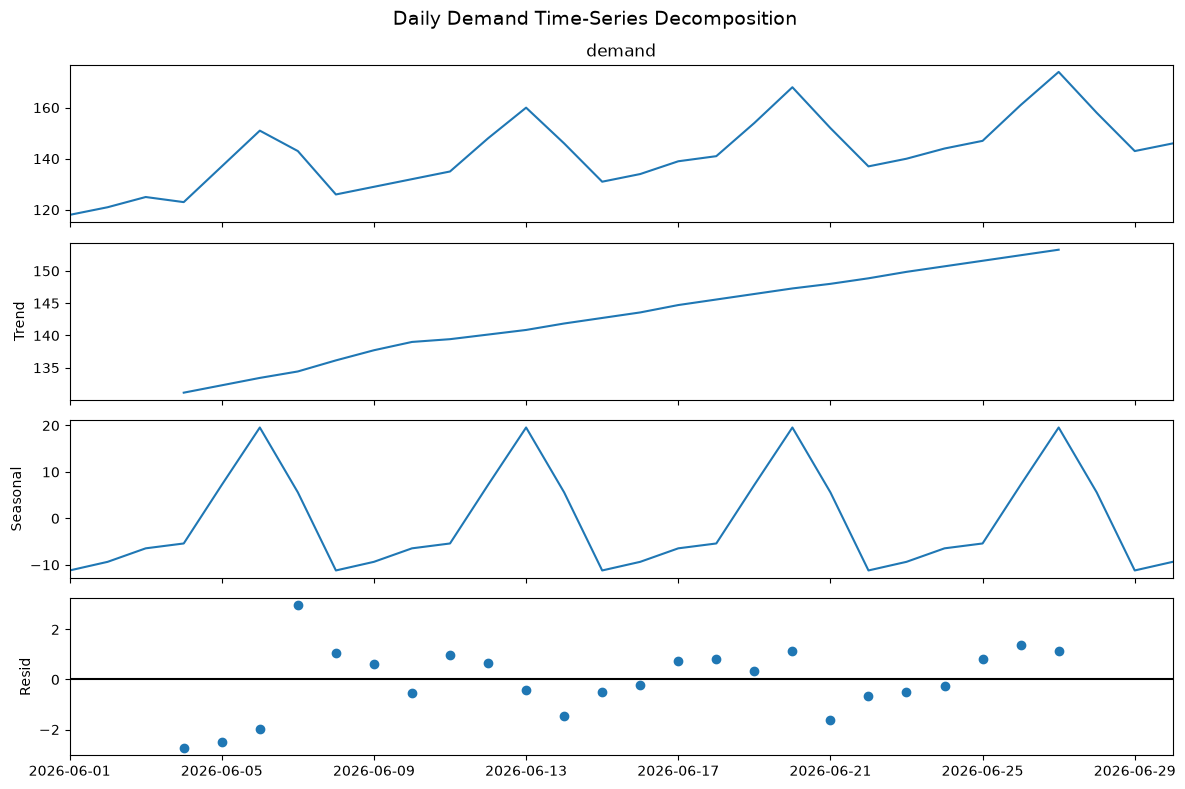

In [20]:
# Decompose the daily demand time series

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.suptitle(
    "Daily Demand Time-Series Decomposition",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [21]:
# Augmented Dickey-Fuller (ADF) test

adf_result = adfuller(ts)

print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))

if adf_result[1] < 0.05:
    print("Result: The time series is stationary.")
else:
    print("Result: The time series is not stationary.")

ADF Statistic: -0.9039
p-value: 0.7867
Result: The time series is not stationary.


Original series length: 30
Differenced series length: 29


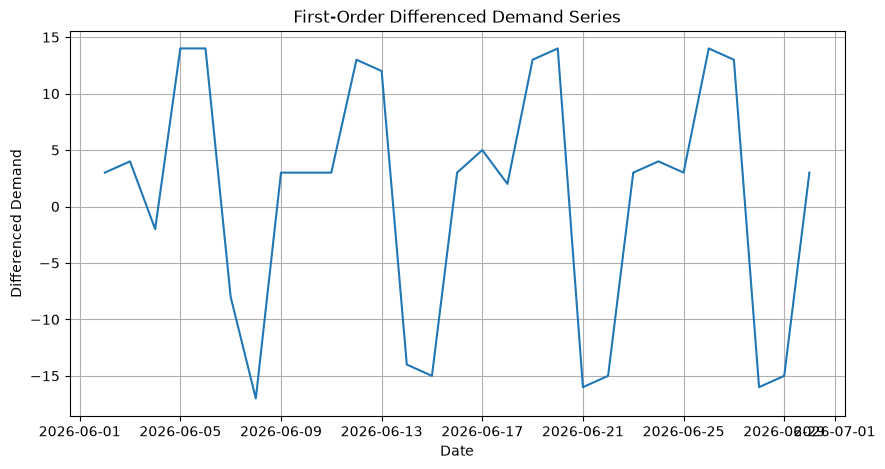

In [22]:
# Apply first-order differencing

ts_diff = ts.diff().dropna()

print("Original series length:", len(ts))
print("Differenced series length:", len(ts_diff))

plt.figure(figsize=(10, 5))

plt.plot(ts_diff)

plt.xlabel("Date")
plt.ylabel("Differenced Demand")
plt.title("First-Order Differenced Demand Series")
plt.grid(True)

plt.show()

In [23]:
# ADF test after first-order differencing

adf_diff = adfuller(ts_diff)

print("ADF Statistic:", round(adf_diff[0], 4))
print("p-value:", round(adf_diff[1], 4))

if adf_diff[1] < 0.05:
    print("Result: The differenced series is stationary.")
else:
    print("Result: The differenced series is still not stationary.")

ADF Statistic: -2.2336
p-value: 0.1943
Result: The differenced series is still not stationary.


In [24]:
# Train-test split
# Last 7 days are kept for testing

train = ts.iloc[:-7]
test = ts.iloc[-7:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 23
Testing observations: 7

Training period:
2026-06-01 00:00:00 to 2026-06-23 00:00:00

Testing period:
2026-06-24 00:00:00 to 2026-06-30 00:00:00


In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("SARIMA imported successfully.")

SARIMA imported successfully.


In [26]:
# SARIMA hyperparameter selection using AIC

import warnings
warnings.filterwarnings("ignore")

results = []

orders = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]

seasonal_orders = [
    (0, 0, 0, 7),
    (0, 1, 0, 7)
]

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted_model.aic
            })

        except Exception as e:
            print("Model failed:", order, seasonal_order)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("AIC").reset_index(drop=True)

print("SARIMA models ranked by AIC:")
display(results_df)

best_order = results_df.loc[0, "order"]
best_seasonal_order = results_df.loc[0, "seasonal_order"]

print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)

SARIMA models ranked by AIC:


,order,seasonal_order,AIC
0,"(0, 1, 1)","(0, 1, 0, 7)",64.315187
1,"(1, 1, 1)","(0, 1, 0, 7)",64.472509
2,"(0, 1, 0)","(0, 1, 0, 7)",66.814911
3,"(1, 1, 0)","(0, 1, 0, 7)",68.420519
4,"(0, 1, 1)","(0, 0, 0, 7)",149.347741
5,"(1, 1, 1)","(0, 0, 0, 7)",151.019581
6,"(0, 1, 0)","(0, 0, 0, 7)",161.273747
7,"(1, 1, 0)","(0, 0, 0, 7)",162.121266


Best order: (0, 1, 1)
Best seasonal order: (0, 1, 0, 7)


In [27]:
# Fit the best SARIMA model

sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                   23
Model:             SARIMAX(0, 1, 1)x(0, 1, [], 7)   Log Likelihood                 -30.158
Date:                            Thu, 08 Oct 2026   AIC                             64.315
Time:                                    22:06:30   BIC                             65.445
Sample:                                06-01-2026   HQIC                            64.083
                                     - 06-23-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5389      0.425     -1.269      0.205      -1.372       0.294
sigma2         6.0486      1.772   

In [28]:
# Forecast the test period

forecast_result = sarima_fit.get_forecast(steps=len(test))
forecast = forecast_result.predicted_mean

print("Forecasted demand:")
print(forecast)

Forecasted demand:
2026-06-24    145.148565
2026-06-25    147.148565
2026-06-26    160.148565
2026-06-27    174.148565
2026-06-28    158.148565
2026-06-29    143.148565
2026-06-30    146.148565
Freq: D, Name: predicted_mean, dtype: float64


In [29]:
# Evaluate the forecast

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("Model Evaluation Results")
print("------------------------")
print("RMSE:", round(rmse, 4))
print("MAPE:", round(mape, 2), "%")

Model Evaluation Results
------------------------
RMSE: 0.5548
MAPE: 0.26 %


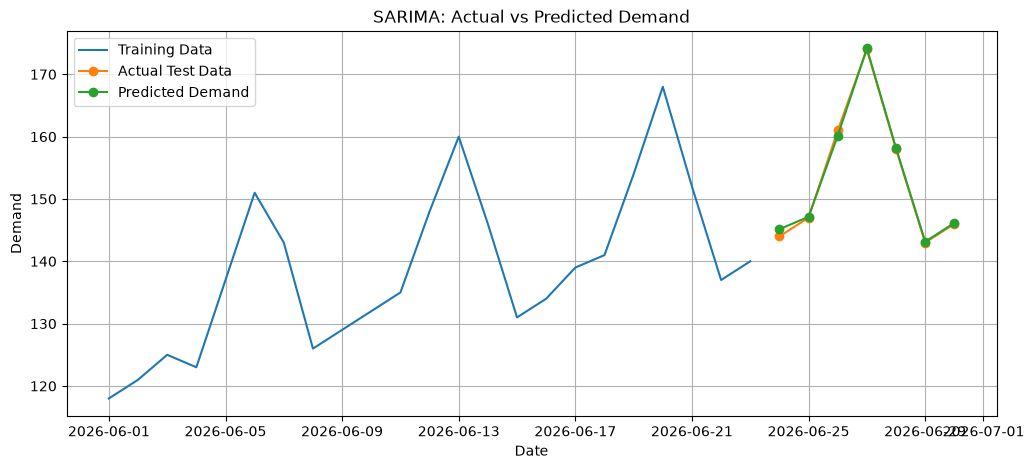

In [30]:
# Actual vs Predicted Demand

plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data", marker="o")
plt.plot(test.index, forecast, label="Predicted Demand", marker="o")

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("SARIMA: Actual vs Predicted Demand")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# 30-day future forecast

final_model = SARIMAX(
    ts,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

future_forecast = final_fit.get_forecast(steps=30)
future_values = future_forecast.predicted_mean

print("30-Day Future Demand Forecast:")
display(future_values)

30-Day Future Demand Forecast:


2026-07-01    150.044408
2026-07-02    153.044408
2026-07-03    167.044408
2026-07-04    180.044408
2026-07-05    164.044408
2026-07-06    149.044408
2026-07-07    152.044408
2026-07-08    156.088815
2026-07-09    159.088815
2026-07-10    173.088815
2026-07-11    186.088815
2026-07-12    170.088815
2026-07-13    155.088815
2026-07-14    158.088815
2026-07-15    162.133223
2026-07-16    165.133223
2026-07-17    179.133223
2026-07-18    192.133223
2026-07-19    176.133223
2026-07-20    161.133223
2026-07-21    164.133223
2026-07-22    168.177630
2026-07-23    171.177630
2026-07-24    185.177630
2026-07-25    198.177630
2026-07-26    182.177630
2026-07-27    167.177630
2026-07-28    170.177630
2026-07-29    174.222038
2026-07-30    177.222038
Freq: D, Name: predicted_mean, dtype: float64

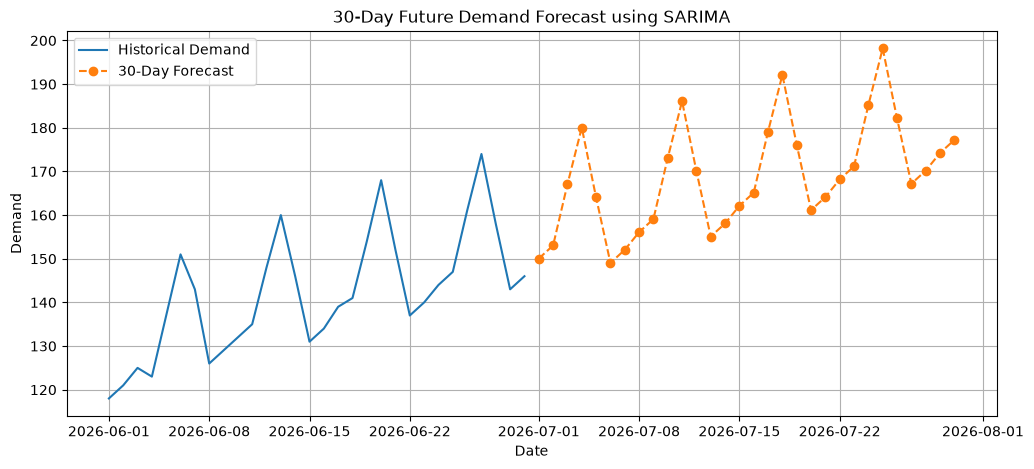

In [32]:
# Plot 30-day future forecast

plt.figure(figsize=(12, 5))

plt.plot(ts.index, ts, label="Historical Demand")
plt.plot(
    future_values.index,
    future_values,
    label="30-Day Forecast",
    linestyle="--",
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("30-Day Future Demand Forecast using SARIMA")
plt.legend()
plt.grid(True)
plt.show()

# Final Conclusions

## Time-Series Analysis
The daily demand series was analyzed using time-series decomposition with a weekly seasonal period of 7 days. The decomposition showed the trend, seasonal, and residual components of the demand series.

## Stationarity Testing
The Augmented Dickey-Fuller (ADF) test on the original series produced a p-value of 0.7867, indicating that the series was non-stationary.

After first-order differencing, the ADF p-value was 0.1943. Since the dataset contains only 30 observations, further differencing was avoided to prevent excessive transformation of the short series.

## SARIMA Model Selection
Several SARIMA configurations were compared using Akaike Information Criterion (AIC). The model with the lowest AIC was selected:

**SARIMA(0,1,1) × (0,1,0,7)**

The selected model captures both